# Stellar Class EDA: which class breaks your score

*An almost-exhaustive EDA: from the raw light to an honest, leak-free baseline.*

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin) · Playground Series S6E6*

Every row in this dataset is one point of light in the sky, and our job is to say what made it: a
**star**, a **galaxy**, or a **quasar** (a galaxy with a feeding black hole at its core). A handful of
brightness numbers is all we get, across 577,347 labelled rows (with 247,435 more to classify). So before
any modelling, one picture: **where do the three kinds of light actually fall?**

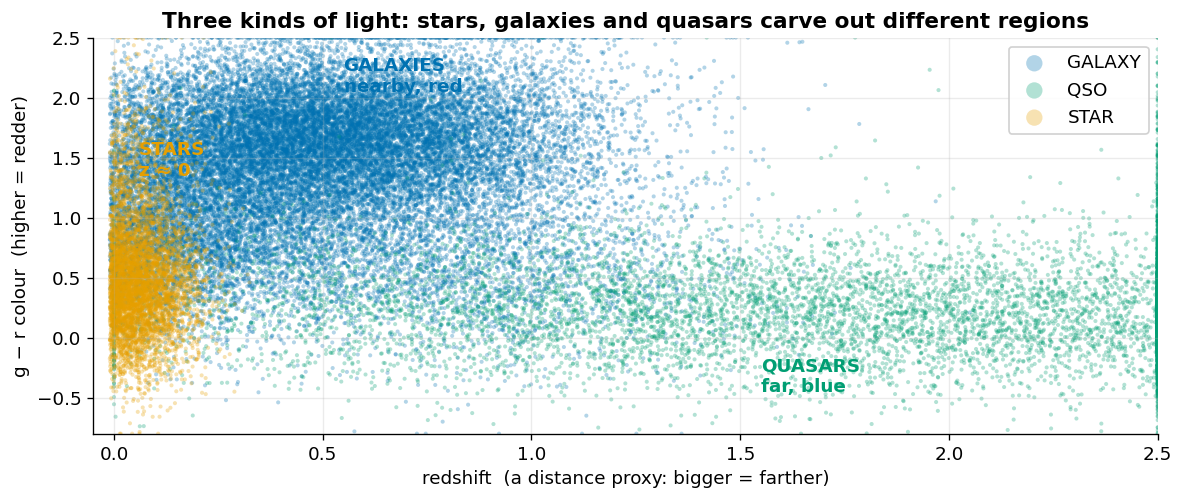

In [1]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection, used in the bonus)
warnings.filterwarnings("ignore")

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything()

# One colourblind-safe colour per class (Okabe-Ito), used everywhere for consistency.
C = {"GALAXY": "#0072B2", "QSO": "#009E73", "STAR": "#E69F00"}
ORDER = ["GALAXY", "QSO", "STAR"]
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

# Find the data wherever it lives: Kaggle mounts competition data under /kaggle/input, but the exact
# sub-path varies (/kaggle/input/<slug>/ or /kaggle/input/competitions/<slug>/), so search recursively.
def find_data():
    for hit in glob.glob("/kaggle/input/**/train.csv", recursive=True):
        return os.path.dirname(hit)
    for p in ["../data", "s6e6/data", "data"]:
        if os.path.exists(os.path.join(p, "train.csv")):
            return p
    raise FileNotFoundError("train.csv not found. /kaggle/input contains: " + str(glob.glob("/kaggle/input/*")))
DATA = find_data()
train = pd.read_csv(os.path.join(DATA, "train.csv"))
test  = pd.read_csv(os.path.join(DATA, "test.csv"))

# First look: where the three classes live, on two of the strongest axes (redshift and one colour).
samp0 = train.sample(40000, random_state=SEED)
gr0 = samp0["g"] - samp0["r"]
fig, ax = plt.subplots(figsize=(10, 4.3))
for cl in ORDER:
    m = (samp0["class"] == cl).values
    ax.scatter(samp0["redshift"].values[m].clip(-0.05, 2.5), gr0.values[m].clip(-0.8, 2.5),
               s=6, alpha=0.30, color=C[cl], edgecolors="none", label=cl)
ax.set_xlim(-0.05, 2.5); ax.set_ylim(-0.8, 2.5)
ax.set_xlabel("redshift  (a distance proxy: bigger = farther)")
ax.set_ylabel("g − r colour  (higher = redder)")
ax.set_title("Three kinds of light: stars, galaxies and quasars carve out different regions",
             fontsize=13, fontweight="bold")
ax.legend(markerscale=4, framealpha=0.9, loc="upper right")
ax.annotate("STARS\nz ≈ 0", xy=(0.06, 1.35), color=C["STAR"], fontsize=11, fontweight="bold")
ax.annotate("GALAXIES\nnearby, red", xy=(0.55, 2.05), color=C["GALAXY"], fontsize=11, fontweight="bold")
ax.annotate("QUASARS\nfar, blue", xy=(1.55, -0.45), color=C["QSO"], fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

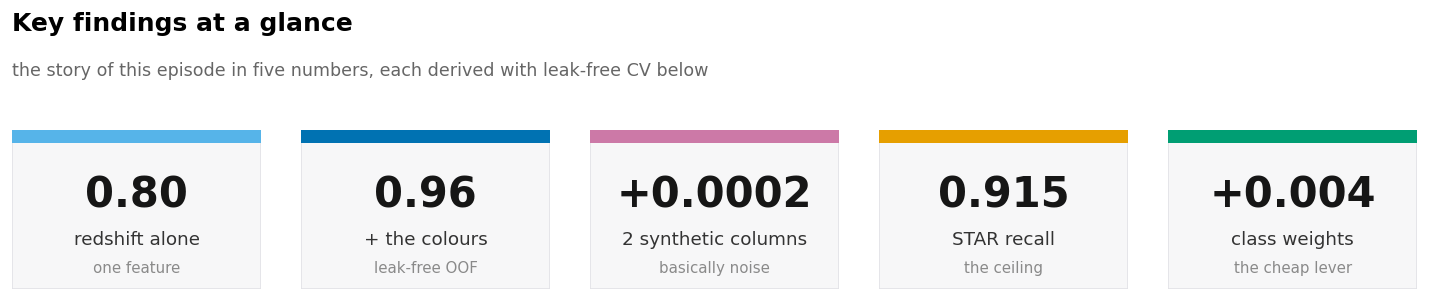

In [2]:
# The whole episode in five numbers, each one measured with leak-free CV later in the notebook.
fig = plt.figure(figsize=(12, 2.5))
fig.text(0.012, 0.93, "Key findings at a glance", ha="left", fontsize=15, fontweight="bold")
fig.text(0.012, 0.78, "the story of this episode in five numbers, each derived with leak-free CV below",
         ha="left", fontsize=10.5, color="#666666")
tiles = [
    ("0.80",    "redshift alone",      "one feature",      "#56B4E9"),
    ("0.96",    "+ the colours",       "leak-free OOF",    "#0072B2"),
    ("+0.0002", "2 synthetic columns", "basically noise",  "#CC79A7"),
    ("0.915",   "STAR recall",         "the ceiling",      "#E69F00"),
    ("+0.004",  "class weights",       "the cheap lever",  "#009E73"),
]
gs = fig.add_gridspec(1, 5, wspace=0.16, left=0.012, right=0.988, top=0.60, bottom=0.07)
for i, (num, lab, sub, col) in enumerate(tiles):
    a = fig.add_subplot(gs[0, i]); a.axis("off")
    a.add_patch(plt.Rectangle((0, 0), 1, 1, transform=a.transAxes, facecolor="#f7f7f8",
                              edgecolor="#e2e2e6", linewidth=1, zorder=0))
    a.add_patch(plt.Rectangle((0, 0.92), 1, 0.08, transform=a.transAxes, facecolor=col, zorder=1))
    a.text(0.5, 0.585, num, transform=a.transAxes, ha="center", va="center",
           fontsize=25, fontweight="bold", color="#161616")
    a.text(0.5, 0.31, lab, transform=a.transAxes, ha="center", va="center", fontsize=11, color="#333333")
    a.text(0.5, 0.13, sub, transform=a.transAxes, ha="center", va="center", fontsize=9, color="#8a8a8a")
plt.show()

*Already the three classes carve out different regions. The rest of this notebook measures how much that
separation is really worth, where it breaks down, and which class quietly caps your score.*

Most EDAs for this episode stop at pretty plots. This one does the half that usually gets skipped: after
we look at the data, we **check whether what we saw actually helps a model**, using cross-validation done
carefully, with no leakage. That turns up a few things the plots alone won't tell you:

- one column already does most of the work, and you can measure exactly how much;
- two columns look strongly tied to the answer yet add **nothing**, and we can show exactly why;
- the whole score hinges on the one class the model keeps getting wrong.

No leaderboard chase here. The top of the board is a wall of tuned blends around 0.973; a clean,
honest baseline lands a bit lower on purpose. The point is to *understand the problem* and leave you a
starting point you can trust and fork.

### What you'll learn
- What the competition's metric (**balanced accuracy**) really rewards, in one picture.
- How far a single feature (**redshift**) really gets you, measured rather than assumed.
- How to read a **colour-colour diagram**, the chart astronomers actually classify by.
- Where the two synthetic columns **come from**, and why that makes them useless to the model.
- Where the model fails, the one knob that moves balanced accuracy most, and why to trust your CV.

### Contents
1. [The task and the metric](#1)
2. [Redshift: the one column that does the heavy lifting](#2)
3. [Colour-colour diagrams: how astronomers tell them apart](#3)
4. [Sky position: a pretty map that barely helps](#4)
5. [Where the synthetic labels come from](#5)
6. [Honest cross-validation: what each feature actually adds](#6)
7. [Where the model fails (and why the metric cares)](#7)
8. [A clean baseline you can fork](#8)
9. [Moving the metric: the one knob that matters](#9)
10. [Trust your CV, not the public leaderboard](#10)
11. [Design choices & limitations](#11)
12. [Further reading](#12)

*Bonus:* [the three classes in 3D](#bonus)

**What the columns mean.** Each row is one observed object.

| column | plain meaning |
|---|---|
| `alpha`, `delta` | where it is in the sky (like longitude and latitude) |
| `u, g, r, i, z` | how bright it is in five colour filters, from ultraviolet (`u`) to infrared (`z`). *Higher = fainter* |
| `redshift` | how much its light is stretched by the expanding universe; in practice, a stand-in for distance |
| `spectral_type` | a category: `O/B`, `A/F`, `G/K`, `M` |
| `galaxy_population` | a category: `Red_Sequence`, `Blue_Cloud` |
| `class` | **what we predict**: `GALAXY`, `QSO` (quasar), or `STAR` |

The difference between two filters is a **colour** (for example `u − g`). Colours describe the *shape* of
an object's light and are what astronomers actually classify on. We build them in §3.

> **Heads-up on two columns.** `spectral_type` and `galaxy_population` are **not** in the original
> astronomy data this episode is built from; the dataset generator added them. They look powerful, but in
> §5 we recover the exact formula behind them, and in §6 we measure what they are actually worth.

In [3]:
# The first few rows, now that we know what each column means.
train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


<a id="1"></a>
## 1. The task and the metric

The three classes are very unevenly sized, and the competition is scored on **balanced accuracy**. Two
quick definitions, because everything hangs on them. *Recall* for a class is: of all the objects that truly
are that class, what fraction did the model catch? *Balanced accuracy* is the average of the three per-class
recalls, so a rare class counts as much as a common one. That one choice changes everything: a lazy model
that always shouts the most common class looks fine on ordinary accuracy and falls apart here.

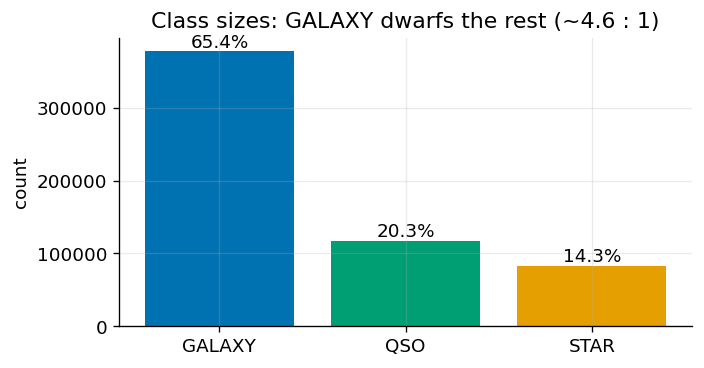

Always guess GALAXY -> ordinary accuracy 0.654  but balanced accuracy 0.333


In [4]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
vc = train["class"].value_counts()[ORDER]
pct = (vc / len(train) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(ORDER, vc.values, color=[C[c] for c in ORDER])
for i, p in enumerate(pct.values):
    ax.text(i, vc.values[i], f"{p}%", ha="center", va="bottom")
ax.set_ylabel("count"); ax.set_title("Class sizes: GALAXY dwarfs the rest (~4.6 : 1)")
plt.tight_layout(); plt.show()

naive = np.full(len(train), "GALAXY")
print(f"Always guess GALAXY -> ordinary accuracy {accuracy_score(train['class'], naive):.3f}"
      f"  but balanced accuracy {balanced_accuracy_score(train['class'], naive):.3f}")

> **Takeaway.** GALAXY is ~65% of the data, so always guessing it scores a respectable-looking 0.65 on
> ordinary accuracy, and a dismal **0.33** on balanced accuracy (one class right out of three). Balanced
> accuracy is the number to chase, and it pays you for getting the *rare* classes, STAR and QSO, right.

<a id="2"></a>
## 2. Redshift: the one column that does the heavy lifting

Before any modelling, one feature stands out, and there's clean physics behind it. **Stars** are our own
galaxy's neighbours, so their light is barely stretched: redshift ≈ 0. **Galaxies** are farther off, so a
bit more. **Quasars** are some of the most distant objects we can see, so the most of all.

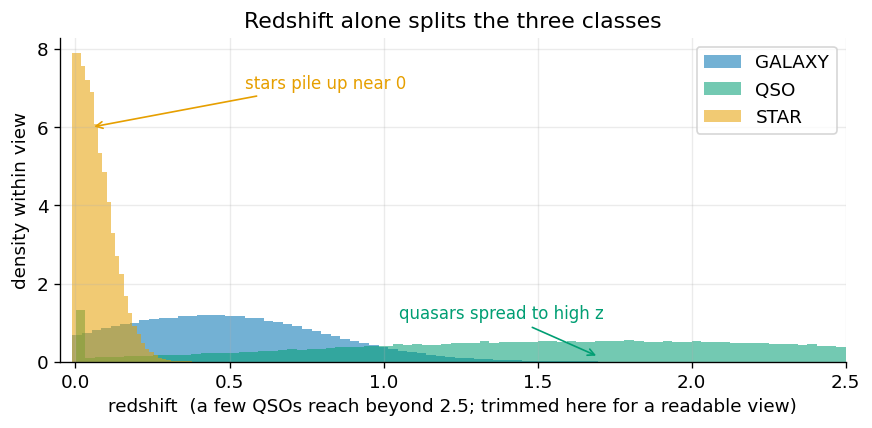

class
GALAXY    0.482
QSO       1.799
STAR      0.056
Name: redshift, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(7.4, 3.7))
for cl in ORDER:                                   # trim the long QSO tail (z>2.5) so it doesn't pile into one bar
    r = train.loc[train["class"] == cl, "redshift"]
    ax.hist(r[(r >= -0.05) & (r <= 2.5)], bins=80, density=True, alpha=0.55, label=cl, color=C[cl])
ax.set_xlim(-0.05, 2.5)
ax.set_xlabel("redshift  (a few QSOs reach beyond 2.5; trimmed here for a readable view)")
ax.set_ylabel("density within view")
ax.set_title("Redshift alone splits the three classes")
ax.annotate("stars pile up near 0", xy=(0.05, 6.0), xytext=(0.55, 7.0),
            color=C["STAR"], fontsize=10, arrowprops=dict(arrowstyle="->", color=C["STAR"]))
ax.annotate("quasars spread to high z", xy=(1.7, 0.12), xytext=(1.05, 1.1),
            color=C["QSO"], fontsize=10, arrowprops=dict(arrowstyle="->", color=C["QSO"]))
ax.legend(); plt.tight_layout(); plt.show()

print(train.groupby("class")["redshift"].median().round(3).reindex(ORDER))

> **Takeaway.** STAR sits at redshift ≈ 0 (inside the Milky Way, no cosmological stretch), GALAXY in the
> low tenths, QSO out past 1. One column carries most of the STAR-versus-rest signal. In §6 we put a number
> on exactly how much, and it turns out to be less than the picture suggests.

<a id="3"></a>
## 3. Colour-colour diagrams: how astronomers tell them apart

A **colour** is one filter minus another. Plotting two colours against each other is the classic way to
separate object types by eye. **How to read it:** each point is an object; tight clumps are a type with a
consistent "shape of light", spread-out smears are a type that varies.

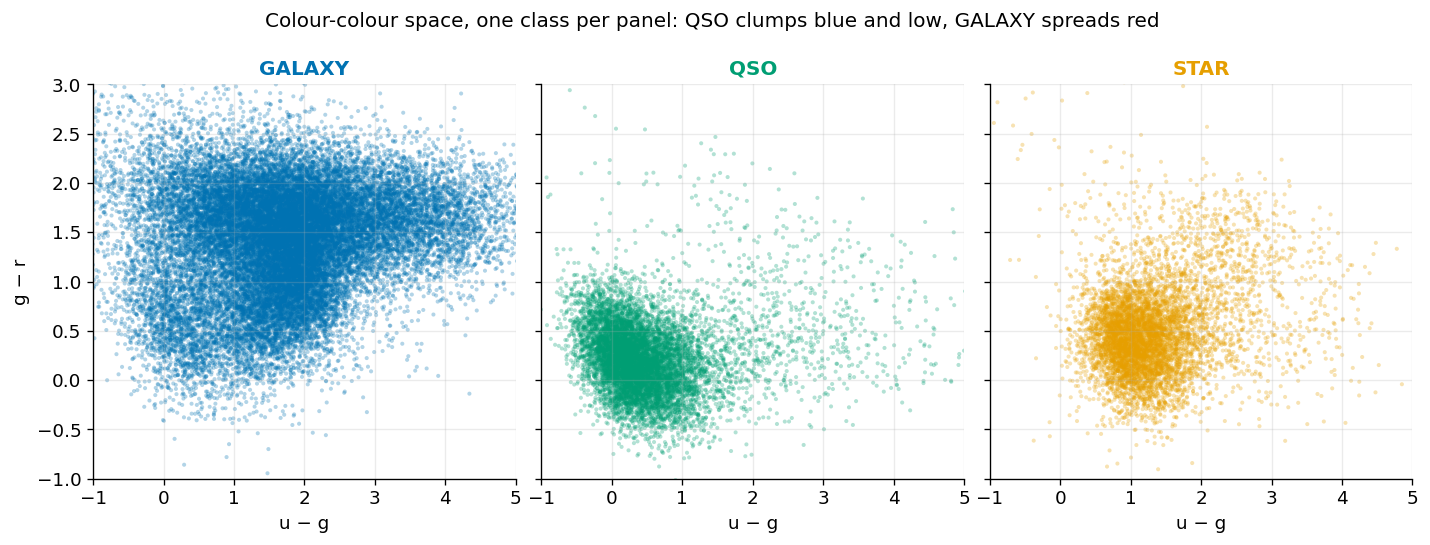

In [6]:
for df in (train, test):
    df["u_g"] = df["u"] - df["g"]; df["g_r"] = df["g"] - df["r"]
    df["r_i"] = df["r"] - df["i"]; df["i_z"] = df["i"] - df["z"]
COLORS = ["u_g", "g_r", "r_i", "i_z"]

samp = train.sample(45000, random_state=SEED)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, cl in zip(axes, ORDER):
    s = samp[samp["class"] == cl]
    ax.scatter(s["u_g"], s["g_r"], s=6, alpha=0.30, color=C[cl], edgecolors="none")
    ax.set_title(cl, color=C[cl], fontsize=12, fontweight="bold")
    ax.set_xlabel("u − g"); ax.set_xlim(-1, 5); ax.set_ylim(-1, 3)
axes[0].set_ylabel("g − r")
fig.suptitle("Colour-colour space, one class per panel: QSO clumps blue and low, GALAXY spreads red",
             fontsize=12)
plt.tight_layout(); plt.show()

> **Takeaway.** Quasars (QSO) sit in a tight, blue, low-colour clump; galaxies sprawl toward red; stars
> fall in between. The colours capture much of what photometry can say about class, which is exactly why,
> in §6, they end up mattering more than the eye-catching category columns.
>
> *One honest caveat: "quasars are blue" holds at low-to-moderate redshift. Near z ≈ 3 to 3.5 their `u − g`
> reddens and they start to look like ordinary stars in this chart, so it isn't a universal rule.*

<a id="4"></a>
## 4. Sky position: a pretty map that barely helps

`alpha` and `delta` are *where* an object sits on the sky (right ascension and declination). It is tempting
to treat them as features. Plotting them shows the survey's footprint, which is genuinely nice to look at, so
let's see whether position actually tells us the class.

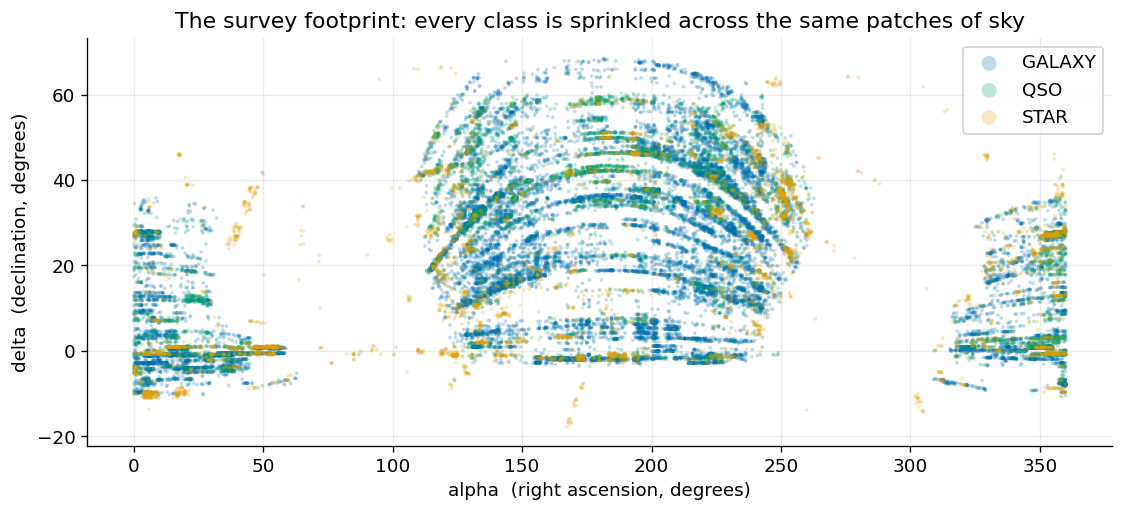

In [7]:
samp_sky = train.sample(35000, random_state=SEED)
fig, ax = plt.subplots(figsize=(9.5, 4.4))
for cl in ORDER:
    s = samp_sky[samp_sky["class"] == cl]
    ax.scatter(s["alpha"], s["delta"], s=5, alpha=0.25, color=C[cl], label=cl, edgecolors="none")
ax.set_xlabel("alpha  (right ascension, degrees)"); ax.set_ylabel("delta  (declination, degrees)")
ax.set_title("The survey footprint: every class is sprinkled across the same patches of sky")
ax.legend(markerscale=4, framealpha=0.9, loc="upper right")
plt.tight_layout(); plt.show()

> **Takeaway.** The footprint is striking, but the three classes are mixed together everywhere; position
> does not cleanly separate them. The mutual-information chart in §6 confirms it: `alpha` and `delta` rank
> near the bottom, far below redshift and the colours. So treat sky position as scenery, not signal. If you
> *do* want to use it, encode `alpha` as `sin`/`cos` (0° and 360° are the same spot, which a tree can't see
> otherwise), and bin the sky into regions. (Thanks to **Noussair Mighri**'s "Sky Positions Features" thread
> for the cyclic-encoding idea.)

<a id="5"></a>
## 5. Where the synthetic labels come from

`spectral_type` and `galaxy_population` look powerful. Inside each category the classes split sharply:

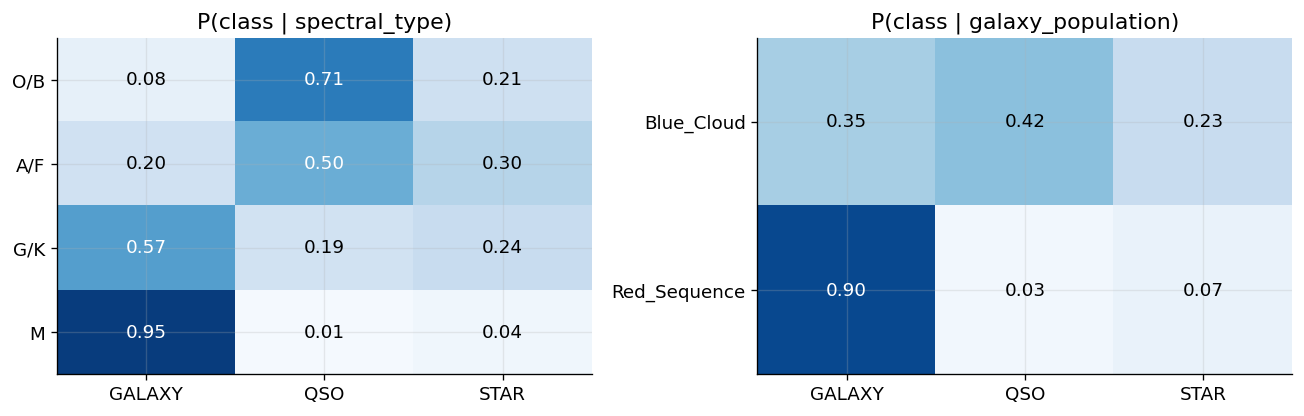

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
row_order = {"spectral_type": ["O/B", "A/F", "G/K", "M"], "galaxy_population": ["Blue_Cloud", "Red_Sequence"]}
for ax, col in zip(axes, ["spectral_type", "galaxy_population"]):
    ctab = pd.crosstab(train[col], train["class"], normalize="index").reindex(row_order[col])[ORDER]
    im = ax.imshow(ctab.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(ORDER)
    ax.set_yticks(range(len(ctab))); ax.set_yticklabels(ctab.index)
    for i in range(ctab.shape[0]):
        for j in range(3):
            v = ctab.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.5 else "black")
    ax.set_title(f"P(class | {col})")
plt.tight_layout(); plt.show()

`spectral_type = M` is 95% GALAXY, `O/B` is mostly QSO, `Red_Sequence` is 90% GALAXY. Strong, right? But
before trusting them, ask where they came from. They are not in the original astronomy data, so the generator
made them, and a quick test reveals exactly how: each one is a **threshold on a single colour**. The cell
below rebuilds both columns from the raw filters and checks the match. (Hat tip to **broccoli beef**'s thread
"Formulae for spectral_type and galaxy_population" for the recipe.)

In [9]:
# spectral_type is just (g - r) cut into 4 bands; galaxy_population is just (u - r) split at 2.2.
def make_spectral_type(g, r):
    return pd.cut(r - g, [-np.inf, -1, -0.5, 0, np.inf], labels=["M", "G/K", "A/F", "O/B"]).astype(str)
def make_galaxy_population(u, r):
    return pd.cut(u - r, [-np.inf, 2.2, np.inf], labels=["Blue_Cloud", "Red_Sequence"]).astype(str)

m1 = (make_spectral_type(train["g"], train["r"]) == train["spectral_type"]).mean()
m2 = (make_galaxy_population(train["u"], train["r"]) == train["galaxy_population"]).mean()
print(f"spectral_type     rebuilt from (g - r): {m1*100:.1f}% exact match")
print(f"galaxy_population rebuilt from (u - r): {m2*100:.1f}% exact match")

spectral_type     rebuilt from (g - r): 100.0% exact match
galaxy_population rebuilt from (u - r): 100.0% exact match


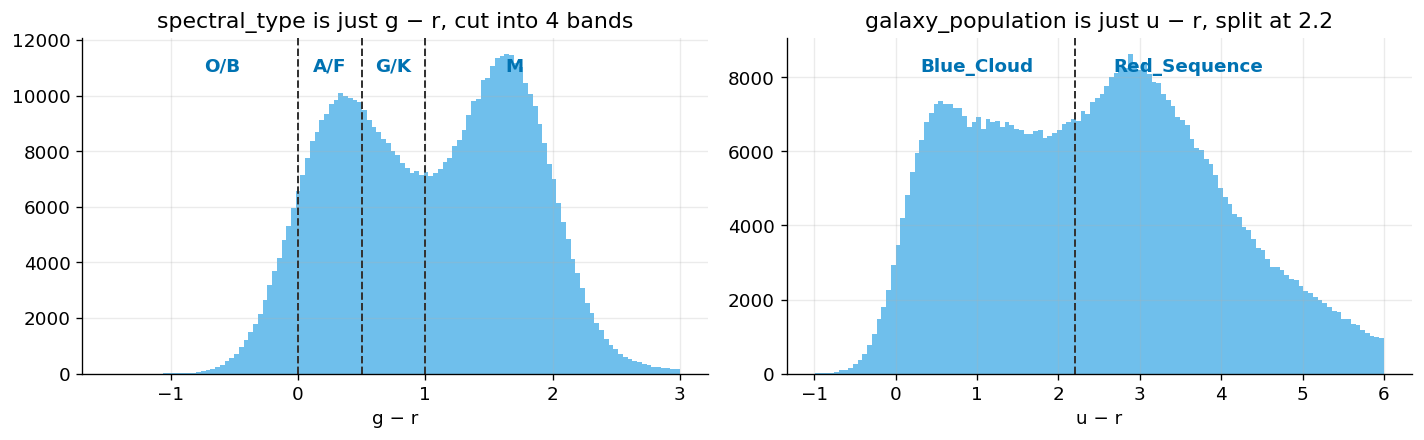

In [10]:
gr = (train["g"] - train["r"]); ur = (train["u"] - train["r"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].hist(gr[(gr > -1.5) & (gr < 3)], bins=120, color="#56B4E9", alpha=0.85)
for t in [0, 0.5, 1.0]:
    axes[0].axvline(t, color="#333333", ls="--", lw=1.2)
for x, name in [(-0.6, "O/B"), (0.25, "A/F"), (0.75, "G/K"), (1.7, "M")]:
    axes[0].text(x, axes[0].get_ylim()[1]*0.9, name, ha="center", fontsize=11, fontweight="bold", color="#0072B2")
axes[0].set_title("spectral_type is just g − r, cut into 4 bands"); axes[0].set_xlabel("g − r")

axes[1].hist(ur[(ur > -1) & (ur < 6)], bins=120, color="#56B4E9", alpha=0.85)
axes[1].axvline(2.2, color="#333333", ls="--", lw=1.2)
axes[1].text(1.0, axes[1].get_ylim()[1]*0.9, "Blue_Cloud", ha="center", fontsize=11, fontweight="bold", color="#0072B2")
axes[1].text(3.6, axes[1].get_ylim()[1]*0.9, "Red_Sequence", ha="center", fontsize=11, fontweight="bold", color="#0072B2")
axes[1].set_title("galaxy_population is just u − r, split at 2.2"); axes[1].set_xlabel("u − r")
plt.tight_layout(); plt.show()

> **Takeaway.** Both columns reproduce essentially 100% from a single colour each: `spectral_type` is `g − r`
> chopped into four bands, `galaxy_population` is `u − r` split at 2.2 (which echoes the real red-sequence
> boundary, `u − r ≈ 2.22`, Strateva et al. 2001). So they are not new information at all; they are a **coarse
> re-coding of colours the model already reads, continuously and in full.** That is the whole reason §6 finds
> they add nothing. (Astronomy aside: real spectral types describe *stars*, not galaxies or quasars, and they
> overlap heavily in `g − r`, so this clean rule is the generator's rough approximation, not the sky's.)

<a id="6"></a>
## 6. Honest cross-validation: what each feature actually adds

To trust a score, we score honestly. We split the data into 5 equal parts (folds) with **StratifiedKFold**,
which keeps the same class proportions in every fold. Each fold is then scored only by a model trained on the
other four, so no row is ever graded by a model that already saw it. Those held-out predictions are called
**out-of-fold (OOF)**, and they are what guard against **leakage**: letting hints from the answer sneak into
training and inflate the score until the real leaderboard punctures it. With honest scoring in place, we can
ask the real question. Starting from redshift, what does each group of features actually *add*?

**First, do those features even look informative on their own?** A standard way to measure that is **mutual
information (MI)**: how much knowing one feature tells you about the class. Higher MI looks more useful. Let's
rank every feature by MI before we trust any of it.

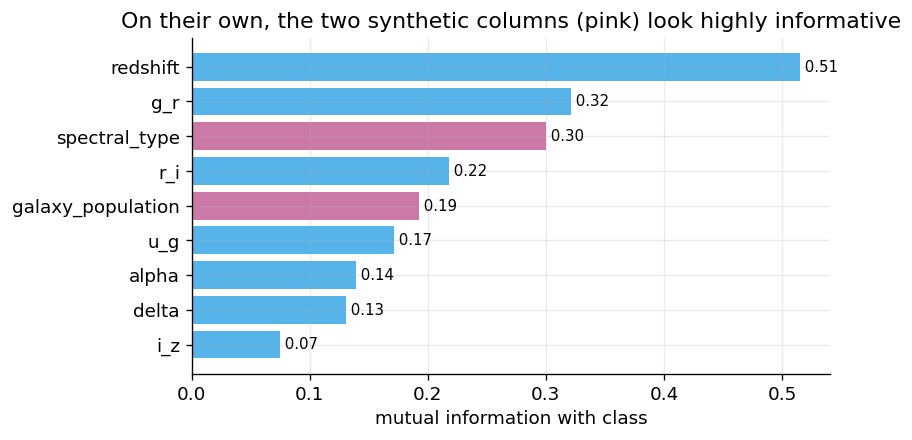

In [11]:
from sklearn.feature_selection import mutual_info_classif
y = train["class"].values
mi_feats = ["redshift", "u_g", "g_r", "r_i", "i_z", "alpha", "delta", "spectral_type", "galaxy_population"]
Xmi = train[mi_feats].copy()
for c in ["spectral_type", "galaxy_population"]:
    Xmi[c] = Xmi[c].astype("category").cat.codes
disc = [f in ("spectral_type", "galaxy_population") for f in mi_feats]
mi = pd.Series(mutual_info_classif(Xmi, y, discrete_features=disc, random_state=SEED),
               index=mi_feats).sort_values()
fig, ax = plt.subplots(figsize=(7.2, 3.8))
bar_c = ["#CC79A7" if f in ("spectral_type", "galaxy_population") else "#56B4E9" for f in mi.index]
ax.barh(mi.index, mi.values, color=bar_c)
for yi, v in enumerate(mi.values):
    ax.text(v, yi, f" {v:.2f}", va="center", fontsize=9)
ax.set_xlabel("mutual information with class")
ax.set_title("On their own, the two synthetic columns (pink) look highly informative")
plt.tight_layout(); plt.show()

By MI, `redshift` leads and the sky positions (`alpha`, `delta`) sit near the bottom, as §4 promised. The two
synthetic columns score high: they *look* like strong features. Now the real test. Does that apparent strength
survive once the model already has the colours they were built from? We add features in groups and measure the
leak-free OOF balanced accuracy at each step.

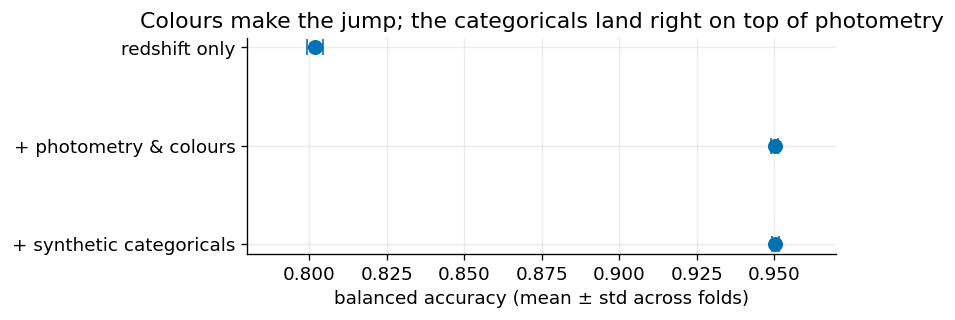

,features,balanced accuracy,adds
0,redshift only,0.8020 ± 0.0026,None
1,+ photometry & colours,0.9501 ± 0.0011,+0.1481
2,+ synthetic categoricals,0.9503 ± 0.0012,+0.0002


In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_score(cols, cat=()):
    X = train[list(cols)].copy()
    for c in cat:
        X[c] = train[c].astype("category").cat.codes
    X = X.values
    cat_idx = [list(cols).index(c) for c in cat]
    s = []
    for tr, va in skf.split(X, y):
        m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, random_state=SEED,
                                           early_stopping=True, categorical_features=cat_idx or None)
        m.fit(X[tr], y[tr]); s.append(balanced_accuracy_score(y[va], m.predict(X[va])))
    return np.array(s)

PHOTO = ["redshift", "u", "g", "r", "i", "z", "alpha", "delta"]   # redshift stays in every richer model
steps = [("redshift only",            cv_score(["redshift"])),
         ("+ photometry & colours",   cv_score(PHOTO + COLORS)),
         ("+ synthetic categoricals", cv_score(PHOTO + COLORS + ["spectral_type", "galaxy_population"],
                                               cat=["spectral_type", "galaxy_population"]))]
tab = pd.DataFrame({"features": [s[0] for s in steps],
                    "balanced accuracy": [f"{s[1].mean():.4f} ± {s[1].std():.4f}" for s in steps]})
tab["adds"] = [None] + [f"{steps[i][1].mean() - steps[i-1][1].mean():+.4f}" for i in range(1, len(steps))]

means = [s[1].mean() for s in steps]; stds = [s[1].std() for s in steps]
fig, ax = plt.subplots(figsize=(7.2, 2.8))
ax.errorbar(means, range(len(steps)), xerr=stds, fmt="o", color="#0072B2", capsize=5, ms=8)
ax.set_yticks(range(len(steps))); ax.set_yticklabels([s[0] for s in steps])
ax.set_xlim(0.78, 0.97); ax.set_xlabel("balanced accuracy (mean ± std across folds)")
ax.set_title("Colours make the jump; the categoricals land right on top of photometry")
ax.invert_yaxis(); plt.tight_layout(); plt.show()
tab

> **Takeaway: the trap of judging a feature alone.** Read the two charts together. On mutual information the
> synthetic columns look like star features. Yet in the ablation, redshift alone reaches **~0.80**, photometry
> and colours push it to **~0.95**, and adding those same high-MI columns moves the score by **about +0.0002**,
> smaller than our own fold-to-fold scatter (±0.0006). That is noise, not signal. We already know why from §5:
> they *are* colour, just coarsely binned, so the model gains nothing it didn't already have. The
> lesson: judge a feature by what it adds **on top of the rest**, not by how it looks on its own. (If you do
> keep them, encode them out-of-fold. Mean-encoding on the full training set quietly leaks the target.)

<a id="7"></a>
## 7. Where the model fails (and why the metric cares)

Balanced accuracy is held down by whichever class the model handles worst. Let's find it with an
out-of-fold confusion matrix. Each row shows where the true members of a class actually land, so the
diagonal is that class's recall.

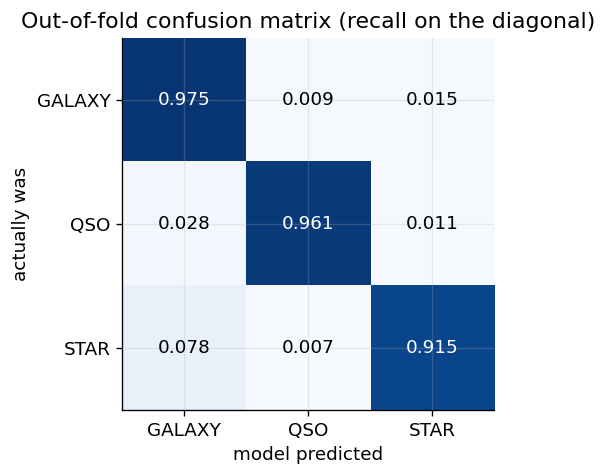

per-class recall: {'GALAXY': np.float64(0.975), 'QSO': np.float64(0.961), 'STAR': np.float64(0.915)}


In [13]:
from sklearn.metrics import confusion_matrix
cols = PHOTO + COLORS + ["spectral_type", "galaxy_population"]
X = train[cols].copy()
for c in ["spectral_type", "galaxy_population"]:
    X[c] = train[c].astype("category").cat.codes
X = X.values
cat_idx = [cols.index(c) for c in ["spectral_type", "galaxy_population"]]
oof_lbl = np.empty(len(train), dtype=object)
for tr, va in skf.split(X, y):
    m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, random_state=SEED,
                                       early_stopping=True, categorical_features=cat_idx)
    m.fit(X[tr], y[tr]); oof_lbl[va] = m.predict(X[va])

cm = confusion_matrix(y, oof_lbl, labels=ORDER)
cmn = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(4.8, 4.1))
ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(ORDER); ax.set_yticks(range(3)); ax.set_yticklabels(ORDER)
ax.set_xlabel("model predicted"); ax.set_ylabel("actually was")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cmn[i,j]:.3f}", ha="center", va="center", color="white" if cmn[i,j] > 0.5 else "black")
ax.set_title("Out-of-fold confusion matrix (recall on the diagonal)")
plt.tight_layout(); plt.show()
print("per-class recall:", {c: round(cmn[i, i], 3) for i, c in enumerate(ORDER)})

> **Takeaway.** GALAXY and QSO land around 0.96 to 0.97, but **STAR is the weak spot (~0.92)**: roughly one
> star in twelve is mistaken for a galaxy, the low-redshift overlap from §2. Because balanced accuracy
> weights classes equally, **STAR alone decides most of your score.** That points straight at the fix in §9.

<a id="8"></a>
## 8. A clean baseline you can fork

Sections 6 and 7 used scikit-learn's HistGradientBoosting to keep the ablation fast and dependency-light. For
the baseline you will actually fork, we switch to **LightGBM**, the Playground workhorse most forks build on;
the picture (STAR is the ceiling) is the same. Same leak-free 5-fold scheme, out-of-fold scoring, and a
submission built from `sample_submission` so the format is guaranteed right. No blending or trickery, just a
clear starting point, not a leaderboard entry.

In [14]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

FEATURES = PHOTO + COLORS + ["spectral_type", "galaxy_population"]
Xtr, Xte = train[FEATURES].copy(), test[FEATURES].copy()
for c in ["spectral_type", "galaxy_population"]:
    Xtr[c] = Xtr[c].astype("category"); Xte[c] = Xte[c].astype("category")
le = LabelEncoder(); ytr = le.fit_transform(train["class"])

params = dict(objective="multiclass", num_class=3, learning_rate=0.05, num_leaves=63,
              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
              min_child_samples=50, seed=SEED, verbose=-1)

oof = np.zeros((len(train), 3)); test_pred = np.zeros((len(test), 3)); fold = []
for k, (tr, va) in enumerate(skf.split(Xtr, ytr)):
    m = lgb.train(params, lgb.Dataset(Xtr.iloc[tr], ytr[tr]),
                  num_boost_round=600, valid_sets=[lgb.Dataset(Xtr.iloc[va], ytr[va])],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    oof[va] = m.predict(Xtr.iloc[va]); test_pred += m.predict(Xte) / skf.n_splits
    fold.append(balanced_accuracy_score(ytr[va], oof[va].argmax(1)))
    print(f"fold {k}: balanced accuracy {fold[-1]:.4f}")
print(f"\nOOF balanced accuracy = {balanced_accuracy_score(ytr, oof.argmax(1)):.4f}  "
      f"({np.mean(fold):.4f} ± {np.std(fold):.4f} across folds)")

fold 0: balanced accuracy 0.9557
fold 1: balanced accuracy 0.9576
fold 2: balanced accuracy 0.9563
fold 3: balanced accuracy 0.9567
fold 4: balanced accuracy 0.9566

OOF balanced accuracy = 0.9566  (0.9566 ± 0.0006 across folds)


<a id="9"></a>
## 9. Moving the metric: the one knob that matters

We know STAR is the bottleneck (§7) and that balanced accuracy rewards per-class recall (§1). So the most
effective lever isn't a fancier model. It's **nudging the model toward the classes it under-calls.** For each
object the model outputs three numbers, its confidence that the object is a GALAXY, a QSO, or a STAR, and
normally picks the biggest. A class *multiplier* gives an under-predicted class like STAR a small thumb on the
scale before that pick, so a few borderline stars get called correctly. We search for good multipliers on the
out-of-fold predictions. This is exactly what the top stacked solutions spend their effort on.

In [15]:
from itertools import product
base = balanced_accuracy_score(ytr, oof.argmax(1))
best_w, best = (1.0, 1.0, 1.0), base
for wq, ws in product([1.0, 1.1, 1.2, 1.3], [1.0, 1.1, 1.2, 1.3, 1.4, 1.5]):   # GALAXY fixed at 1.0
    w = np.array([1.0, wq, ws])                        # le.classes_ order: GALAXY, QSO, STAR
    sc = balanced_accuracy_score(ytr, (oof * w).argmax(1))
    if sc > best: best, best_w = sc, (1.0, wq, ws)
print(f"OOF balanced accuracy:  plain argmax {base:.4f}  ->  class weights {best_w} {best:.4f}")

sub = pd.read_csv(os.path.join(DATA, "sample_submission.csv"))
sub["class"] = le.inverse_transform((test_pred * np.array(best_w)).argmax(1))
assert len(sub) == len(test) and (sub["id"].values == test["id"].values).all()
sub.to_csv("submission.csv", index=False)
print("submission.csv written:", sub.shape)
sub.head()

OOF balanced accuracy:  plain argmax 0.9566  ->  class weights (1.0, 1.3, 1.5) 0.9604
submission.csv written: (247435, 2)


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


> **Takeaway.** A few cheap multipliers lift the rare classes' recall and nudge balanced accuracy up, more
> than most model tweaks would. One honest caveat that matters: we both *chose* and *scored* the multipliers
> on the same out-of-fold data, so treat +0.0038 as an optimistic upper bound, not a guaranteed gain. Trust
> the direction, confirm the real size on the leaderboard, and don't over-fit your own CV, which is exactly
> what §10 is about.

### Does calibrating the probabilities help?

A natural follow-up to the weights: instead of nudging classes, should we **calibrate** the probabilities so
they match observed frequencies? Calibration (here, per-class isotonic regression) is the right fix for a proper
scoring rule like log loss. But balanced accuracy only reads the final argmax, and rescaling each class
monotonically rarely changes which class wins, so the two levers do different jobs. Let's measure both. (We fit
and check on the same out-of-fold predictions, so read the numbers as directional, like the weights above.)

In [16]:
# Does calibration move balanced accuracy? Compare raw OOF, per-class isotonic calibration, and the §9 weights.
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import log_loss

Y1h = np.eye(3)[ytr]
cal = np.column_stack([IsotonicRegression(out_of_bounds="clip").fit_transform(oof[:, c], Y1h[:, c])
                       for c in range(3)])
cal = cal / cal.sum(1, keepdims=True)
wj = oof * np.array(best_w); wj = wj / wj.sum(1, keepdims=True)

for name, P in [("raw OOF", oof), ("isotonic-calibrated", cal), ("class weights (§9)", wj)]:
    print(f"{name:20s} log loss {log_loss(ytr, P):.4f}   balanced accuracy {balanced_accuracy_score(ytr, P.argmax(1)):.4f}")

raw OOF              log loss 0.0894   balanced accuracy 0.9566
isotonic-calibrated  log loss 0.0889   balanced accuracy 0.9572
class weights (§9)   log loss 0.0907   balanced accuracy 0.9604


> **Takeaway.** Per-class calibration lowers log loss but leaves balanced accuracy essentially where it was; the
> §9 class weights do the reverse, lifting balanced accuracy while *raising* log loss. Neither is "better": they
> serve different metrics. If a competition scores you on log loss, calibrate. Here, where the metric is balanced
> accuracy, the decision rule (per-class weights or thresholds) is the lever, and calibrating first changes
> nothing about which class wins. Match the tool to the metric.

<a id="10"></a>
## 10. Trust your CV, not the public leaderboard

This is the question the discussion tab keeps circling back to. Our honest out-of-fold score is **0.9566**,
and it barely moves across folds. The public leaderboard top sits near **0.973**. Before you chase that gap,
look at where it comes from.

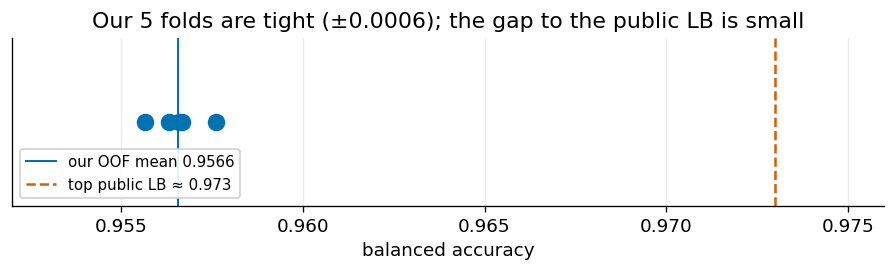

In [17]:
fig, ax = plt.subplots(figsize=(7.6, 2.4))
ax.scatter(fold, [0] * len(fold), s=90, color="#0072B2", zorder=3)
ax.axvline(np.mean(fold), color="#0072B2", lw=1.2, label=f"our OOF mean {np.mean(fold):.4f}")
ax.axvline(0.973, color="#D55E00", ls="--", lw=1.5, label="top public LB ≈ 0.973")
ax.set_yticks([]); ax.set_xlim(0.952, 0.976); ax.set_xlabel("balanced accuracy")
ax.set_title(f"Our 5 folds are tight (±{np.std(fold):.4f}); the gap to the public LB is small")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
plt.tight_layout(); plt.show()

> **Takeaway.** Our five folds land on top of each other, so the CV is trustworthy. Part of the leaderboard's
> lead over it is not better modelling, it is **public-split probing**: some top public notebooks "ridge-flip"
> labels using public-LB feedback, which fits the public slice and is unlikely to survive the hidden private
> split. Strong models here agree on almost every row and only disagree in a few hard cases, so the public
> ranking comes down partly to luck. The practical rule, echoed by top competitors in the forum: **pick your
> final submissions by CV, not by public LB**, and expect a shake-up. Don't be discouraged by a modest public
> rank. A disciplined CV can gain you hundreds of places once the private board is revealed.

### Postscript: how the episode resolved

The competition has closed, and it went the way §10 argued. A large shake-up hit the public leaderboard. Chris Deotte's [week-1 public starter](https://www.kaggle.com/competitions/playground-series-s6e6/writeups/25th-place-my-public-starter-notebook) placed 25th, with a CV of 0.9703 that matched its private 0.9702 almost exactly, and the finishers who wrote up their approach had selected on cross-validation rather than the public score.

Three numbers from the final board make the point concrete. The links go to each author's write-up, worth reading in full:
- The winner climbed from 344th on the public leaderboard to 1st on the private one, having chosen his final submissions on cross-validation rather than public score; the entry that won had a lower public LB than others he was holding ([Optimistix, 1st](https://www.kaggle.com/competitions/playground-series-s6e6/writeups/1st-place-mission-300-accomplished)).
- More models bought almost nothing: the 6th-place stack used 92 models and still beat the single strongest public out-of-fold stacker by only 0.0004 balanced accuracy, 0.97035 to 0.97072 ([Andreas Palmgren, 6th](https://www.kaggle.com/competitions/playground-series-s6e6/writeups/6th-place-solution-trusting-the-oof-plateau)).
- Chasing the public score actively hurt: one competitor's plain 5-seed blend scored 0.97051 public and held 0.97021 private, while his public-feedback-tuned version reached 0.97260 public but dropped to 0.97001 private ([Alvin Li's post-mortem](https://www.kaggle.com/competitions/playground-series-s6e6/writeups/bitter-lesson-from-a-278-place-shakedown)).

Two refinements from the top solutions are worth taking, and both sit on §6 and §9:
- Balanced accuracy is a noisy argmax metric, so the [8th-place solution](https://www.kaggle.com/competitions/playground-series-s6e6/writeups/8th-place-solution) validated on **class-weighted log-loss** instead (weights proportional to 1 over the class prior). That is a strictly proper, lower-variance surrogate with the same optimal decision, and you take the argmax only at the end.
- The balanced-accuracy-optimal rule has a closed form: divide each class posterior by its prior, then argmax (`argmax P(y=c|x) / P(y=c)`). The §9 weight search is the tuned version of that same correction; you can also reach it by weighting the loss by 1/prior, or by training unweighted and dividing by the prior afterward.

Thanks to Jerry for working through the maths in the 8th-place write-up, and to the finishers linked above for sharing how they did it.

<a id="11"></a>
## 11. Design choices & limitations

- **Honest CV.** StratifiedKFold matches the random test split; categories are passed straight to the tree
  (no target-encoding), so nothing leaks in to inflate the score.
- **Baseline, not a podium.** No blending or pseudo-labelling. It sits a little under the tuned public blends
  (~0.973) on purpose: the value is the *why*, plus a base clean enough to build on.
- **The synthetic columns add no real lift** (§5, §6). They are binned colours; if you mean-encode them,
  do it out-of-fold or you'll fool your own CV.
- **Sky position is scenery** (§4). `alpha` / `delta` rank lowest on MI; spend your feature-engineering time
  on colours and redshift instead.
- **STAR is the ceiling** (§7, §9). Class weights are the quickest win; a redshift-aware feature or per-class
  thresholds are the next places to look.

<a id="12"></a>
## 12. Further reading

The S6E6 Code and Discussion tabs are full of good work. A short, honest path through it, with credit to the
authors and threads that shaped this notebook:

### From this episode

**The recipe behind the synthetic columns.**
[Formulae for spectral_type and galaxy_population](https://www.kaggle.com/competitions/playground-series-s6e6/discussion/703535)
by broccoli beef. The discussion thread that reverse-engineers the two generated columns (the source for §5).

**For the astronomy.** [Exploring Space (EDA)](https://www.kaggle.com/code/aryankaisth/s6e6-exploring-space-eda)
by Aryan Kaisth. The episode's best domain primer; it even pulls real telescope cutouts from the SDSS
SkyServer to show what each class looks like. Read it for intuition.

**For the leaderboard ceiling.**
[GPU Logistic Regression Stacker](https://www.kaggle.com/code/cdeotte/gpu-logistic-regression-stacker)
by Chris Deotte (Grandmaster). The canonical top-of-stack: a meta-model blending many bases, with class
weighting and a STAR boost, the §9 idea taken all the way.

**For the same idea with a twist.**
[TabPFN-3 Stacker](https://www.kaggle.com/code/philippsinger/tabpfn-3-stacker) by Philipp Singer
(Grandmaster). Swaps the meta-learner for TabPFN-3 with probability balancing, a clean look at biasing
toward minority recall.

**For a strong single model to fork.**
[RealMLP · PyTorch](https://www.kaggle.com/code/yekenot/ps-s6-e6-realmlp-pytorch) by Vladimir Demidov. A
from-scratch neural net with the colour and redshift features the astronomy predicts.

### Beyond this episode

These pick up where this notebook stops, grouped by what you might do next. They are not about Stellar Class,
the skills transfer.

*When your real problem is class imbalance.*
[Credit Fraud: Dealing with Imbalanced Datasets](https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets)
by Janio Martinez Bachmann. The go-to beginner walkthrough of imbalanced data: why accuracy lies, undersampling
versus SMOTE, and the rule to resample *inside* each CV fold, never before. It is a binary case using F1/ROC, so
carry over the lessons, not the exact metric.

*Judging whether a feature earns its place.*
[Mutual Information](https://www.kaggle.com/code/ryanholbrook/mutual-information) by Ryan Holbrook (Kaggle Learn).
The source lesson on the very metric behind our §6 high-MI trap: compute MI yourself, then see why a high-MI
feature can still add no lift.
[Permutation Importance](https://www.kaggle.com/code/dansbecker/permutation-importance) by Dan Becker (Kaggle
Learn). A clear short intro to ranking a feature by how far the score drops when you shuffle it, the lift it
really adds. Read it right after §6, and score it on balanced accuracy.

*Keeping your validation honest.*
[Data Leakage](https://www.kaggle.com/code/alexisbcook/data-leakage) by Alexis Cook (Kaggle Learn). The canonical
short lesson on target leakage and train-test contamination, the bug that makes your CV look great while the
leaderboard collapses.

*When you are ready to push the score.*
[Introduction to Ensembling/Stacking in Python](https://www.kaggle.com/code/arthurtok/introduction-to-ensembling-stacking-in-python)
by Anisotropic (Arthur Tok), Grandmaster. The classic, widely used walkthrough of leak-free out-of-fold stacking
with a second-level model, where §9 leads once a single LightGBM plateaus. Adapt the pattern to multiclass.

*A broader tabular toolkit.*
[Data Science for Tabular Data: Advanced Techniques](https://www.kaggle.com/code/vbmokin/data-science-for-tabular-data-advanced-techniques)
by Vitalii Mokin (Grandmaster). A practical, reusable tour of feature engineering, tuning, and stacking for
tabular problems once you want to push past a single model.

### Playground Series, honest walkthroughs (mine)

A running series: one careful EDA-to-baseline notebook per episode, same playbook, different data.

<div align="center"><a href="https://www.kaggle.com/code/georgymamarin/student-health-risk-why-86-accuracy-scores-0-33">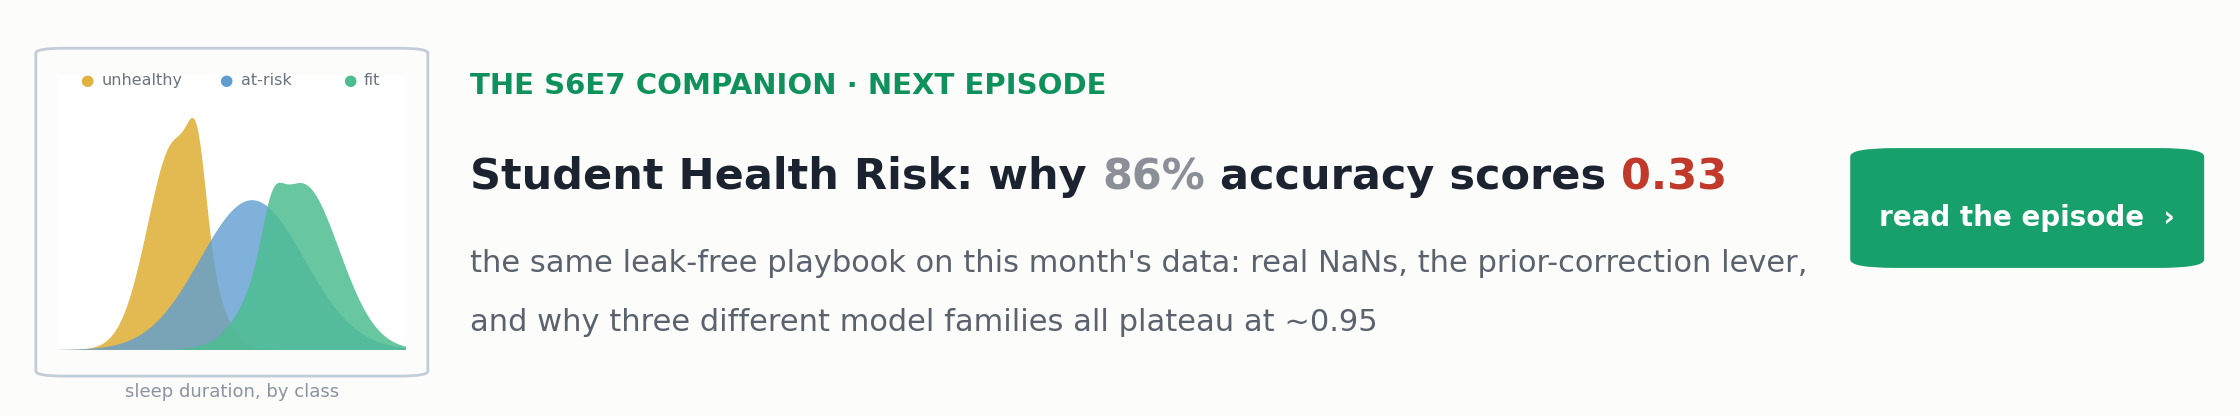</a></div>

[**Student Health Risk: why 86% accuracy scores 0.33 (S6E7)**](https://www.kaggle.com/code/georgymamarin/student-health-risk-why-86-accuracy-scores-0-33). The next episode, in full: the same leak-free playbook on a dataset with real missing values, the prior-correction lever, and why three different model families all plateau at ~0.95.

### More honest write-ups (mine)

A few of my own notebooks in the same honest spirit, in case the validation angle resonated.

[Stop reforking: where the ROGII error actually lives](https://www.kaggle.com/code/georgymamarin/stop-reforking-where-the-error-actually-lives).
A ROGII write-up separating the error you can squeeze out of the data from the part that is simply irreducible.

[Agents Grading Agents: Spaceship Titanic MLE-bench](https://www.kaggle.com/code/georgymamarin/agents-grading-agents-spaceship-titanic-mle-bench).
A different lane: LLM agents doing the modelling themselves, graded on the MLE-bench benchmark.

[NeuroGolf Survival Kit](https://www.kaggle.com/code/georgymamarin/neurogolf-survival-kit).
The same honest-tooling spirit on NeuroGolf, an ONNX size-golf contest: a local scorer and a pre-submit validator.

<a id="bonus"></a>
## Bonus: the three classes in 3D

A view for the curious, outside the main thread. It shows the same separation we measured above, now across
three feature axes at once: redshift, `g − r` and `u − g`, drawn from two angles. It adds no new signal (the
third axis mostly echoes the colours); it just makes the clusters tangible.

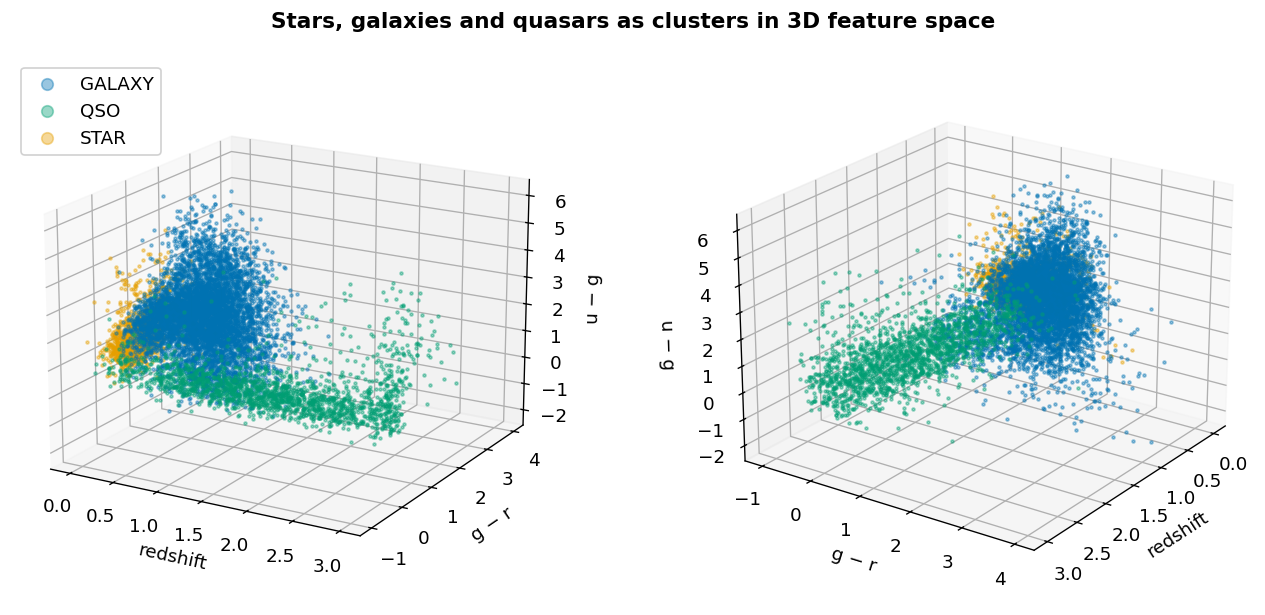

In [18]:
# Static 3D so it always renders inline (no external JS): the same clusters from two viewing angles.
s3d = train.sample(9000, random_state=SEED)
xs = s3d["redshift"].clip(-0.05, 3).values
ys = (s3d["g"] - s3d["r"]).clip(-1, 4).values
zs = (s3d["u"] - s3d["g"]).clip(-2, 6).values
cls = s3d["class"].values
fig = plt.figure(figsize=(12, 5.2))
for k, (elev, azim) in enumerate([(18, -60), (22, 35)]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    for cl in ORDER:
        m = cls == cl
        ax.scatter(xs[m], ys[m], zs[m], s=3, alpha=0.4, color=C[cl], label=cl, depthshade=False)
    ax.set_xlabel("redshift"); ax.set_ylabel("g − r"); ax.set_zlabel("u − g")
    ax.view_init(elev=elev, azim=azim)
    if k == 0:
        ax.legend(markerscale=4, loc="upper left", framealpha=0.9)
fig.suptitle("Stars, galaxies and quasars as clusters in 3D feature space", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

---

### Credits & a small ask

Thanks to the Kaggle Playground team for a clean, genuinely teachable dataset, and to the discussion-tab
authors credited above. If reading the data before modelling it helped, or if §9 nudged your STAR recall, an
**upvote** keeps this in reach of the next person starting the episode. I read every comment; tell me which
feature finally moved your score. Fork away.

*[Georgy Mamarin](https://www.kaggle.com/georgymamarin)*